In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('../Our Datasets/features_sample_match.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

cols_to_drop = ['Unique ID', 'match_id', 'event_index', 'frame_anchor', 'rec_player_id', 'rec_team_short', 'start_type', 'end_type', 'event_row_index', 
                'source_file', 'error', 'dist_to_near_goal', 'dist_to_far_goal', 'third_end']

df = df.drop(columns=cols_to_drop)

In [20]:
df.head(5)

,dist_to_attacking_goal,d_nearest_opp,n_opp_within5,d_nearest_team,mean_team_dist,n_forward_options,game_state,team_out_of_possession_phase_type,third_start,max_player_targeted_xthreat
0,99.575170,7.026308,0.0,8.593788,31.734731,10.0,drawing,high_block,defensive,0.0024
3,34.427403,0.000000,1.0,7.359348,27.331335,9.0,drawing,chaotic,attacking,0.0091
9,82.713146,4.389533,1.0,2.603114,13.502075,0.0,drawing,chaotic,attacking,0.0091
14,51.188596,2.489598,2.0,6.110491,23.968649,7.0,drawing,chaotic,middle,0.0359
19,47.054798,0.982700,1.0,11.608070,23.278395,8.0,drawing,chaotic,middle,0.0359


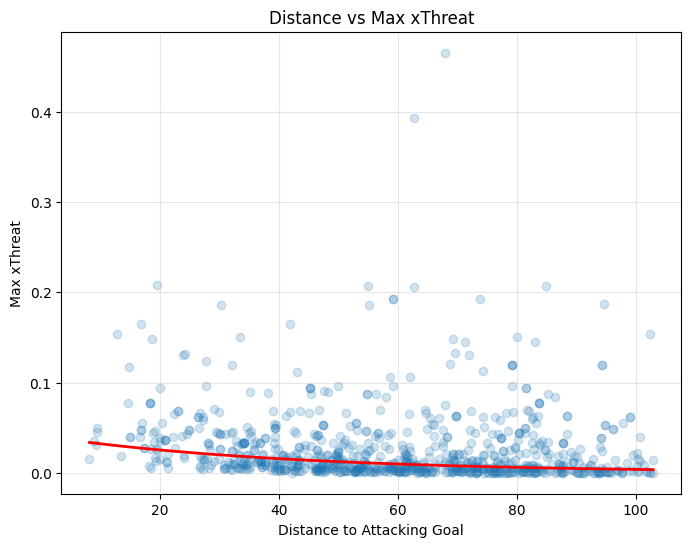

In [21]:
tmp = df[['dist_to_attacking_goal','max_player_targeted_xthreat']].dropna()
x = tmp['dist_to_attacking_goal'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Distance to Attacking Goal')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

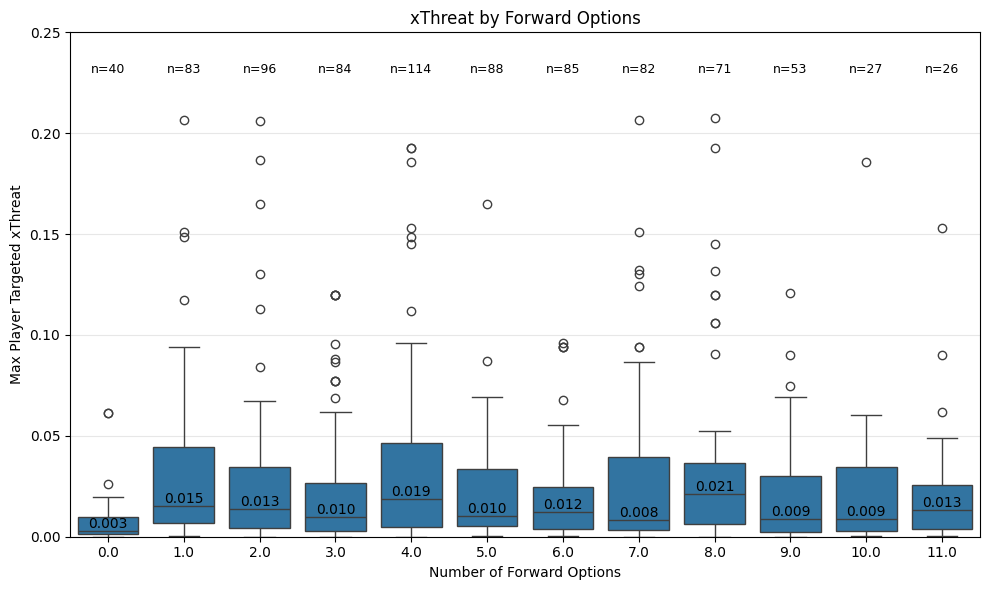

In [22]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='n_forward_options',
    y='max_player_targeted_xthreat',
    ax=ax
)

counts = df.groupby('n_forward_options')['max_player_targeted_xthreat'].count()
medians  = df.groupby('n_forward_options')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()
    opt_val  = float(opt_text)

    # average
    m = medians.loc[opt_val]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

    # count – leave above or remove if you want
    n = counts.loc[opt_val]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Number of Forward Options')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Forward Options')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


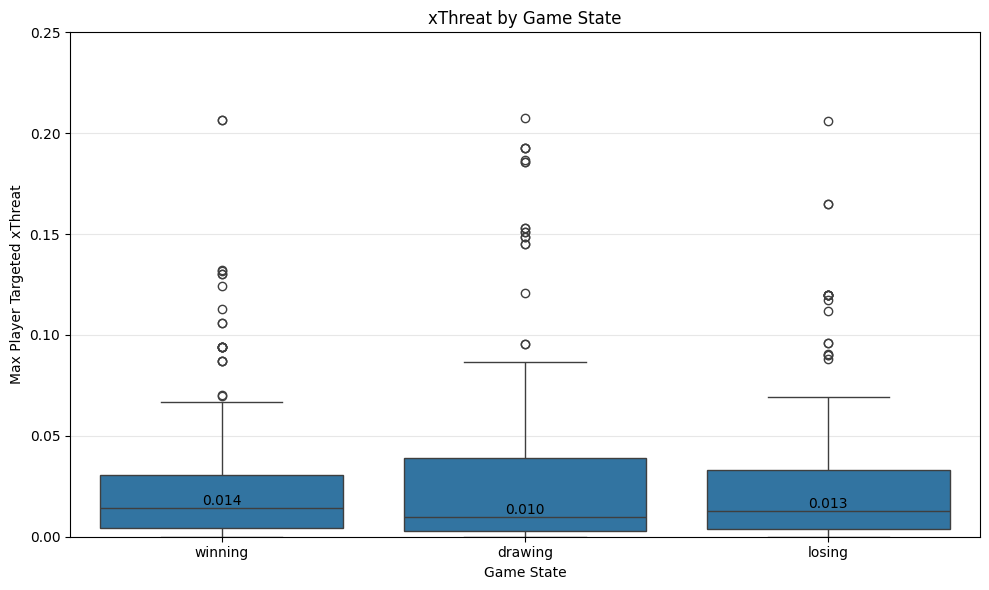

In [23]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='game_state',
    y='max_player_targeted_xthreat',
    order=['winning','drawing','losing'],   # <-- here
    ax=ax
)

counts = df.groupby('game_state')['max_player_targeted_xthreat'].count()
medians  = df.groupby('game_state')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Game State')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Game State')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


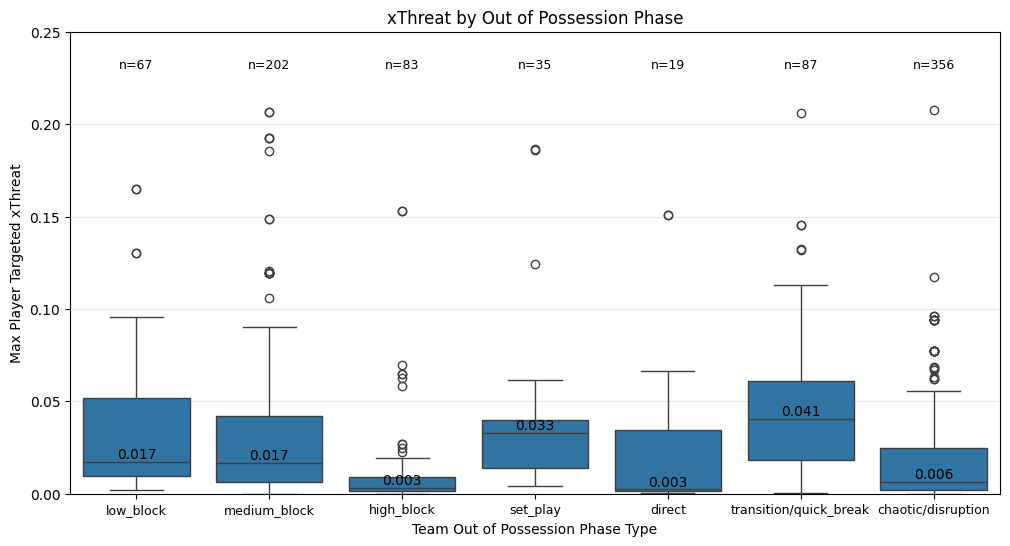

In [24]:
fig, ax = plt.subplots(figsize=(12,6))

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_direct': 'direct',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)

sns.boxplot(
    data=df,
    x='team_out_of_possession_phase_type',
    y='max_player_targeted_xthreat',
    order=['low_block','medium_block','high_block', 'set_play', 'direct', 'transition/quick_break', 'chaotic/disruption'],   # <-- here
    ax=ax
)

counts = df.groupby('team_out_of_possession_phase_type')['max_player_targeted_xthreat'].count()
medians  = df.groupby('team_out_of_possession_phase_type')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

        # count – leave above or remove if you want
    n = counts.loc[opt_text]
    ax.text(
        tick,
        .23,          # slightly above the mean
        f'n={n}',
        ha='center',
        fontsize=9,
        color='black'
    )

ax.set_xlabel('Team Out of Possession Phase Type')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Out of Possession Phase')
ax.grid(axis='y', alpha=0.3)

plt.xticks(fontsize=9)

ax.set_ylim(0, 0.25)

plt.show()


Looks like high_block, set_play, direct, transition, quick_break, chaotic, and disruption are significant. I think we could combine transition and quick_break and chaotic and disruption.

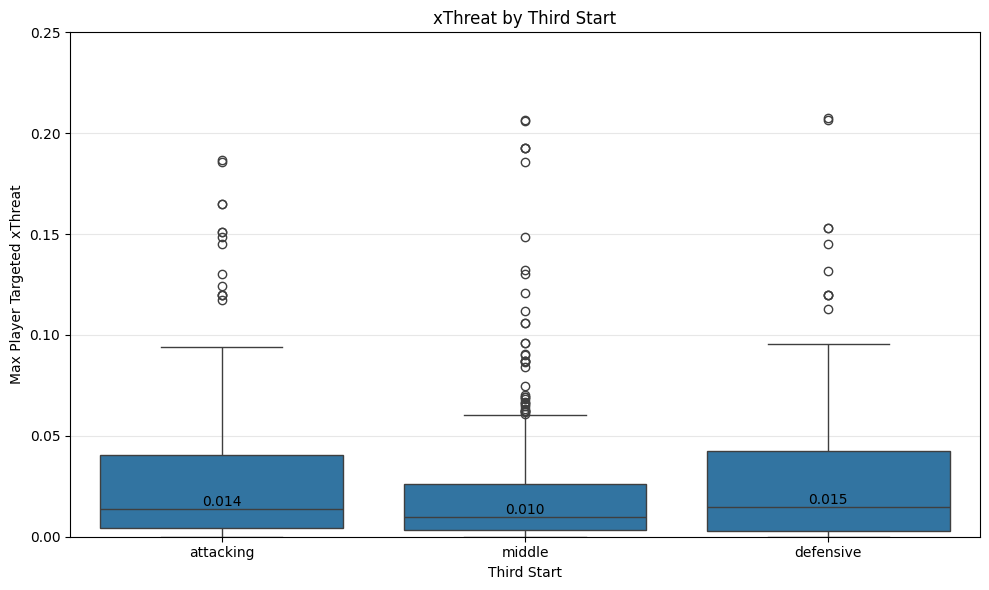

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='third_start',
    y='max_player_targeted_xthreat',
    order=['attacking','middle','defensive'],   # <-- here
    ax=ax
)

counts = df.groupby('third_start')['max_player_targeted_xthreat'].count()
medians  = df.groupby('third_start')['max_player_targeted_xthreat'].median()

for tick, label in enumerate(ax.get_xticklabels()):
    opt_text = label.get_text()

    # average
    m = medians.loc[opt_text]
    ax.text(
        tick,
        m,
        f'{m:.3f}',       # label is the mean
        ha='center',
        va='bottom',
        color='black'
    )

ax.set_xlabel('Third Start')
ax.set_ylabel('Max Player Targeted xThreat')
ax.set_title('xThreat by Third Start')
ax.grid(axis='y', alpha=0.3)

ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()


Why is defensive higher than middle?

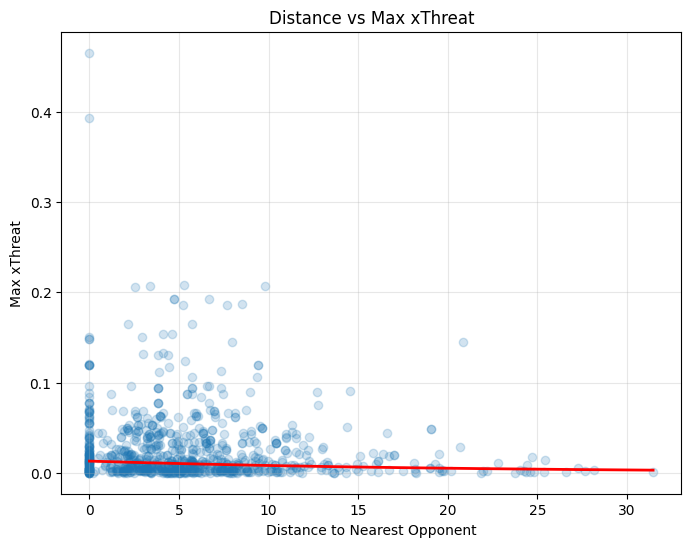

In [26]:
tmp = df[['d_nearest_opp','max_player_targeted_xthreat']].dropna()
x = tmp['d_nearest_opp'].values
y = tmp['max_player_targeted_xthreat'].values

# only positive y for log
mask = y > 0
x = x[mask]
y = y[mask]

# fit log(y)
coef = np.polyfit(x, np.log(y), 1)
b = coef[0]
log_a = coef[1]
a = np.exp(log_a)

# generate xs
xs = np.linspace(x.min(), x.max(), 200)
ys = a * np.exp(b * xs)  # exponential curve

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.2)
plt.plot(xs, ys, color='red', linewidth=2)

plt.xlabel('Distance to Nearest Opponent')
plt.ylabel('Max xThreat')
plt.title('Distance vs Max xThreat')
plt.grid(True, alpha=0.3)

plt.show()

Not much of a relationship here, maybe slight exponential?